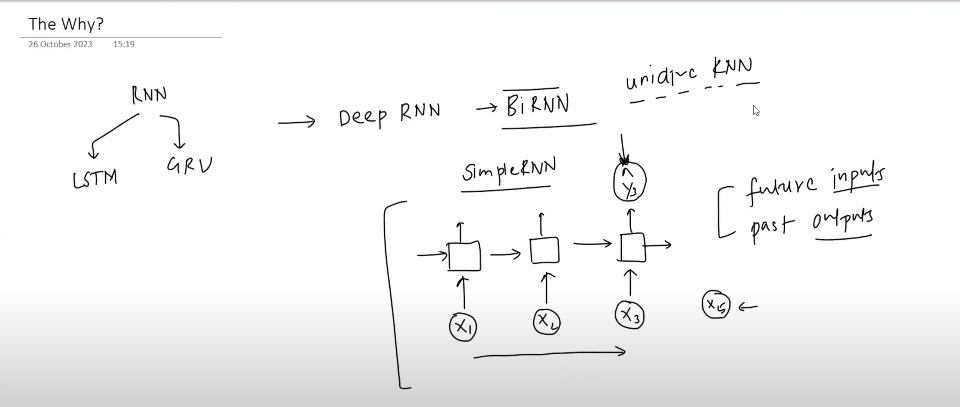

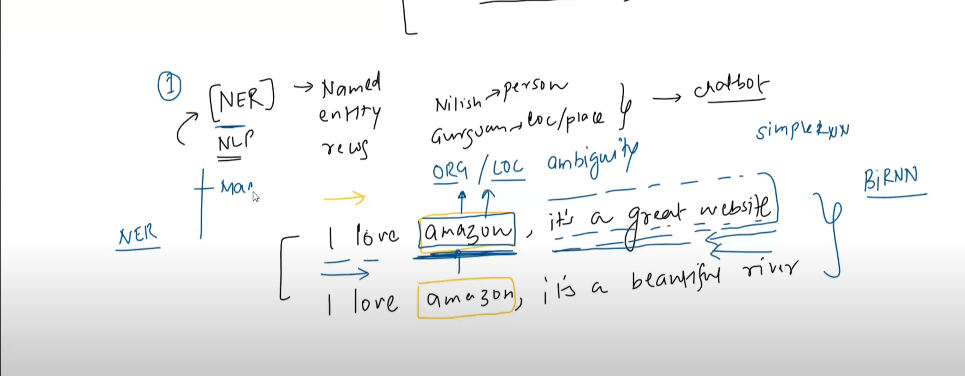

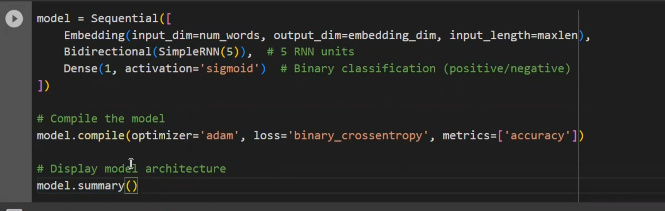

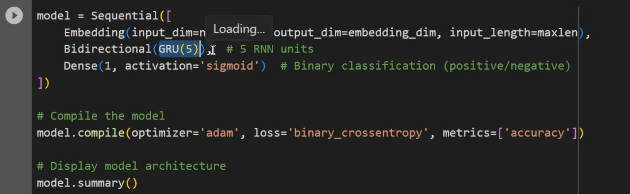

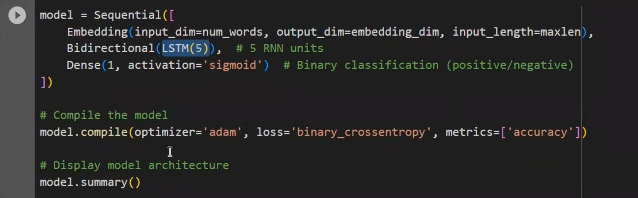

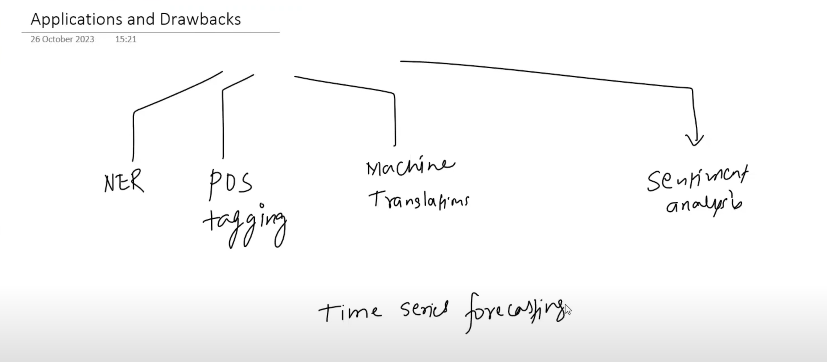

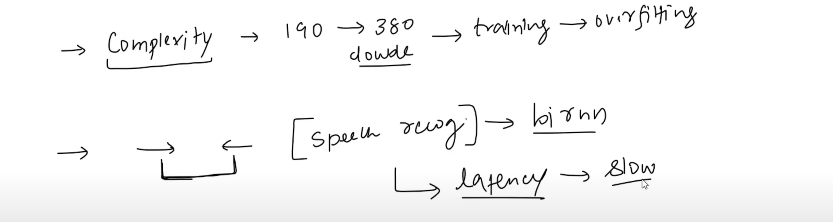



---

## 🌟 Why Bidirectional RNN? (The "Why?")

In Natural Language Processing (NLP), context matters. For example:

> **"I love Amazon, it’s a great website."**  
> vs  
> **"I love Amazon, it’s a beautiful river."**

👉 The word **"Amazon"** can mean:
- A company (ORG) → first sentence
- A river (LOC) → second sentence

So, understanding the meaning of "Amazon" depends on **both**:
- What came **before** it
- What comes **after** it

But standard RNNs only look **forward** (left to right). That’s why we need **Bidirectional RNNs (BiRNN)** — they look **both ways**!

---

# 🔁 1. Simple RNN: The Foundation

### 🧱 Architecture
A basic RNN processes sequences step by step:

```
x₁ → [RNN] → h₁ → y₁
     ↑       ↑
     x₂ → [RNN] → h₂ → y₂
     ↑       ↑
     x₃ → [RNN] → h₃ → y₃
```

- `x_t`: input at time t
- `h_t`: hidden state (memory)
- `y_t`: output at time t

### 🧮 Simple Math (Simplified)

```python
h_t = tanh(W * [h_{t-1}, x_t] + b)
y_t = softmax(W_out * h_t + b_out)
```

- `W`, `b`: learnable weights & biases
- `tanh`: activation function (squashes values between -1 and 1)

### ❌ Problem: Vanishing Gradient
- Long sequences → gradients get smaller → model forgets early inputs
- So RNNs struggle with long-term dependencies

---

# 🚀 2. LSTM: Long Short-Term Memory

### ✅ Designed to fix RNN's memory problem

LSTM adds **gates** to control what to remember or forget.

### 🔍 Architecture (4 Parts)

Think of an LSTM cell like a **memory box** with 3 gates:

| Gate | Purpose |
|------|--------|
| **Forget gate** | Decide what to forget from past memory |
| **Input gate** | Decide what new info to store |
| **Output gate** | Decide what to output |

#### 🧮 Simple Math (Step-by-step)

Let’s say we have:
- `h_{t-1}`: previous hidden state
- `c_{t-1}`: previous cell state (long-term memory)
- `x_t`: current input

```python
# Forget gate: decide what to forget
f_t = sigmoid(W_f · [h_{t-1}, x_t] + b_f)

# Input gate: decide what to update
i_t = sigmoid(W_i · [h_{t-1}, x_t] + b_i)
~_t = tanh(W_c · [h_{t-1}, x_t] + b_c)

# Update cell state
c_t = f_t * c_{t-1} + i_t * ~_t

# Output gate: decide what to output
o_t = sigmoid(W_o · [h_{t-1}, x_t] + b_o)
h_t = o_t * tanh(c_t)
```

✅ **Intuition**:  
- `c_t` is like a **notebook** that keeps important facts
- Gates are like **editors** who decide what to write, erase, or show

---

# ⚡ 3. GRU: Gated Recurrent Unit

GRU is a **simpler version of LSTM** – fewer gates, faster training.

### 🔍 Architecture

Only **2 gates**:
- **Reset gate**: how much past info to ignore
- **Update gate**: how much to copy from past

### 🧮 Simple Math

```python
# Reset gate: forget old info?
r_t = sigmoid(W_r · [h_{t-1}, x_t] + b_r)

# Update gate: keep or replace?
z_t = sigmoid(W_z · [h_{t-1}, x_t] + b_z)

# Candidate hidden state
~_t = tanh(W · [r_t * h_{t-1}, x_t] + b)

# Final hidden state
h_t = (1 - z_t) * h_{t-1} + z_t * ~_t
```

✅ **Pros**: Simpler than LSTM, trains faster  
❌ **Cons**: Slightly less powerful than LSTM for complex tasks

---

# 🔁 4. Bidirectional RNN (BiRNN): See Both Ways!

### 🧠 Intuition

Instead of just going left→right, BiRNN runs **two RNNs**:
- One forward: sees past context
- One backward: sees future context

Then combines both outputs.

```
Forward RNN:   x₁ → x₂ → x₃ → x₄
               ↓    ↓    ↓    ↓
              h₁   h₂   h₃   h₄

Backward RNN:  x₄ ← x₃ ← x₂ ← x₁
               ↓    ↓    ↓    ↓
              h₄'  h₃'  h₂'  h₁'

Final output: h_t = [h_t, h_t']  → concatenate
```

So now each word knows about **everything before AND after it**!

### 💡 Example: "Amazon"

- Forward RNN sees: “I love Amazon…” → thinks it might be a company
- Backward RNN sees: “…beautiful river” → thinks it’s a place
- Combined → better decision: **Amazon = river**

---

# 💻 5. Keras Code Examples

Let’s build a **BiLSTM** for NER (Named Entity Recognition).

```python
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout

# Example: NER task
model = Sequential([
    Embedding(input_dim=10000, output_dim=128, input_length=100),
    Bidirectional(LSTM(64, return_sequences=True)),  # BiLSTM layer
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(num_tags, activation='softmax')  # e.g., 5 tags: PERSON, LOC, ORG, etc.
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
```

### 📝 Notes:
- `input_dim`: vocab size
- `output_dim`: embedding size
- `return_sequences=True`: output for every timestep (needed for sequence labeling)
- `Bidirectional()`: wraps any RNN (LSTM, GRU, RNN)

---

# ✅ Pros & Cons

| Model | Pros | Cons |
|-------|------|------|
| **Simple RNN** | Easy to understand | Struggles with long sequences |
| **LSTM** | Handles long-term memory well | Complex, slow to train |
| **GRU** | Faster than LSTM, simpler | Slightly weaker than LSTM |
| **BiRNN** | Uses full context (past + future) | Needs more memory, not good for real-time |

---

# 🎯 When to Use?

| Task | Best Choice |
|------|-------------|
| Text classification (e.g., sentiment) | BiLSTM or BiGRU |
| Speech recognition | LSTM or GRU |
| Real-time chatbot (no future input) | Uni-directional LSTM |
| NER, POS tagging | **BiLSTM** (best performance) |

---

# 🧠 Summary: From Scratch to Practice

| Step | Explanation |
|------|-------------|
| 1️⃣ **Problem**: Words can be ambiguous without context |
| 2️⃣ **Solution**: Use bidirectional models |
| 3️⃣ **Core Idea**: Two RNNs (forward + backward) → full context |
| 4️⃣ **Memory Fix**: LSTM/GRU help remember long sequences |
| 5️⃣ **Code**: Use `Bidirectional(LSTM(...))` in Keras |
| 6️⃣ **Result**: Better accuracy in NLP tasks like NER |

---

# 🧩 Bonus: Your Handwritten Notes Explained

Your drawings show:
- **NER**: Extracting entities (person, location, org)
- **Ambiguity**: "Amazon" could be company or river
- **BiRNN**: Solves ambiguity by seeing both sides
- **Unidirectional RNN**: Only sees past → misses future context

👉 **That’s exactly why BiRNNs are powerful!**

---

# 📚 Recap (Simple Terms)

| Concept | What It Does |
|--------|--------------|
| **RNN** | Reads text one word at a time, remembers some things |
| **LSTM** | Smarter RNN that remembers long-term stuff |
| **GRU** | Simpler version of LSTM |
| **BiRNN** | Runs two RNNs: one forward, one backward → sees full context |

---

# ✅ Final Tip

For **NER, translation, sentiment analysis**, use:
```python
Bidirectional(LSTM(64))
```





---

### ❓ What is a bidirectional RNN?  
✅ It reads text **forward and backward** to understand context better.

---

### ❓ Why use it?  
✅ Words like "Amazon" can mean different things.  
→ Forward: "I love Amazon..."  
→ Backward: "...beautiful river"  
🔁 Together → model knows it’s a **river**, not a company.

---

### ❓ What’s wrong with normal RNN?  
❌ Forgets old info (vanishing gradient).  
❌ Only sees past, not future.

---

### ❓ How does LSTM fix this?  
🧠 LSTM has **memory** and **gates**:
- **Forget gate**: decides what to erase
- **Input gate**: decides what to save
- **Output gate**: decides what to show

→ Remembers long sequences.

---

### ❓ What is GRU?  
⚡ Like LSTM, but simpler:
- Only 2 gates: **reset** and **update**
- Faster to train, almost as good as LSTM

---

### ❓ What is BiLSTM / BiGRU?  
🔁 Bidirectional + LSTM/GRU  
→ One layer reads left-to-right  
→ One reads right-to-left  
→ Combine both → best context

---

### ❓ When to use bidirectional models?  
✅ Use when you have **full sentence** (not real-time):  
- Named Entity Recognition (NER)  
- Sentiment analysis  
- Text tagging

🚫 Don’t use in real-time chat (can’t see future words).

---

### ❓ Code in Keras?  
```python
Bidirectional(LSTM(64))
```
or
```python
Bidirectional(GRU(64))
```

---

### ❓ Pros and Cons?

| Model | Pros | Cons |
|------|------|------|
| RNN | Simple | Forgets fast |
| LSTM | Strong memory | Slow |
| GRU | Fast, simple | Slightly weaker |
| BiRNN | Full context | Needs full input |

---

